In [1]:
import pandas as pd

In [2]:
Data = pd.read_excel("Online_Retail.xlsx")
Data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Data Understanding

In [3]:
rows, cols = Data.shape
print(f"Rows: {rows}, Columns: {cols}")

Rows: 541909, Columns: 8


In [4]:
Data.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [5]:
# Statistical Summary
Data.describe(include='all')
#top- most common(mode)
#freq- count of top

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [6]:
# unique invoice numbers are the total no. of orders.
# top of description is the most ordered product.
# max of invoice date is the latest order. 

In [7]:
Data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
#duplicate value ananlysis

## Data Cleaning and Preprocessing

In [9]:
Data.dropna(subset=['CustomerID'], inplace=True)
Data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [10]:
#removing duplicate records
#handling cancelled transactions
# Drops rows where EITHER column1 OR column2 is less than 1
Data.drop(Data[(Data['Quantity'] < 1) | (Data['UnitPrice'] < 1)].index, inplace=True)
Data.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,304911.0,304911,304911,304911.000000,304911,304911.000000,304911.000000,304911
unique,18185.0,3049,3230,NaN,NaN,NaN,NaN,37
top,576339.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,489.0,2035,2028,NaN,NaN,NaN,NaN,271313
mean,NaN,NaN,NaN,10.255898,2011-07-08 14:45:08.094690048,3.883633,15297.045351,NaN
min,NaN,NaN,NaN,1.000000,2010-12-01 08:26:00,1.000000,12346.000000,NaN
25%,NaN,NaN,NaN,2.000000,2011-04-03 14:42:00,1.650000,13975.000000,NaN
50%,NaN,NaN,NaN,4.000000,2011-07-28 11:18:00,2.460000,15153.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 16:41:00,4.250000,16805.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,NaN


Text(0, 0.5, 'Price')

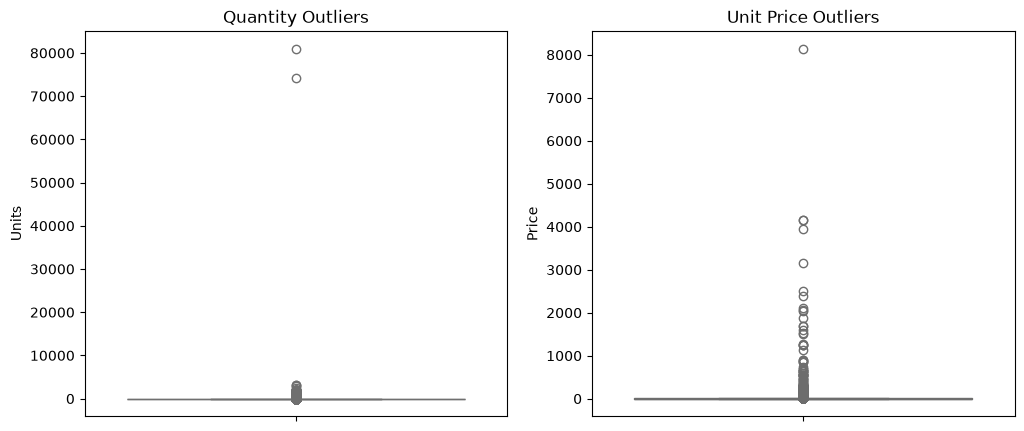

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create a 1-row, 2-column layout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=Data, y='Quantity', ax=axes[0], color='skyblue')
axes[0].set_title('Quantity Outliers')
axes[0].set_ylabel('Units')

sns.boxplot(data=Data, y='UnitPrice', ax=axes[1], color='salmon')
axes[1].set_title('Unit Price Outliers')
axes[1].set_ylabel('Price')

In [12]:
import numpy as np

print("--- Skewness Scores ---")
print(f"Quantity Skewness:  {Data['Quantity'].skew():.2f}")
print(f"UnitPrice Skewness: {Data['UnitPrice'].skew():.2f}")

--- Skewness Scores ---
Quantity Skewness:  377.13
UnitPrice Skewness: 179.59


In [13]:
# log transformations 
Data['Quantity_Log'] = np.log1p(Data['Quantity'])
Data['UnitPrice_Log'] = np.log1p(Data['UnitPrice'])

print("--- Final Optimized Skewness Scores ---")
print(f"Quantity_Log Skewness:  {Data['Quantity_Log'].skew():.2f}")
print(f"UnitPrice_Log Skewness: {Data['UnitPrice_Log'].skew():.2f}")

--- Final Optimized Skewness Scores ---
Quantity_Log Skewness:  1.00
UnitPrice_Log Skewness: 1.38


In [14]:
Data['CustomerID'] = Data['CustomerID'].astype('object')
print(Data['CustomerID'].dtypes)

object


In [15]:
Data.dtypes

InvoiceNo                object
StockCode                object
Description              object
Quantity                  int64
InvoiceDate      datetime64[ns]
UnitPrice               float64
CustomerID               object
Country                  object
Quantity_Log            float64
UnitPrice_Log           float64
dtype: object

In [16]:
Data['Month'] = Data['InvoiceDate'].dt.month
Data['Day_of_Week'] = Data['InvoiceDate'].dt.dayofweek  # 0 = Monday, 6 = Sunday
Data['Day_of_Month'] = Data['InvoiceDate'].dt.day
Data['Hour'] = Data['InvoiceDate'].dt.hour

Data['Is_Weekend'] = Data['Day_of_Week'].isin([5, 6]).astype(int)
Data['Is_EOM'] = Data['InvoiceDate'].dt.is_month_end.astype(int)  

In [17]:
Data['TotalPrice'] = Data['Quantity'] * Data['UnitPrice']

Data['Is_Bulk_Order'] = (Data['Quantity'] > 1000).astype(int)

In [18]:
Data['Is_UK'] = (Data['Country'] == 'United Kingdom').astype(int)

# (Frequency Encoding)
stock_counts = Data['StockCode'].value_counts()
Data['StockCode_Popularity'] = Data['StockCode'].map(stock_counts)

In [19]:
customer_order_counts = Data['CustomerID'].value_counts()
Data['Customer_Order_Frequency'] = Data['CustomerID'].map(customer_order_counts).fillna(0)

In [20]:
Data['TotalPrice_Log'] = np.log1p(Data['TotalPrice'])
print(f"TotalPrice_Log Skewness: {Data['TotalPrice_Log'].skew():.2f}")

TotalPrice_Log Skewness: 0.52


## EDA

In [21]:
numeric_cols = ['Quantity', 'UnitPrice', 'TotalPrice']
print(Data[numeric_cols].describe().round(2))

        Quantity  UnitPrice  TotalPrice
count  304911.00  304911.00   304911.00
mean       10.26       3.88       25.79
std       201.45      25.19      352.53
min         1.00       1.00        1.00
25%         2.00       1.65        5.80
50%         4.00       2.46       15.00
75%        10.00       4.25       20.00
max     80995.00    8142.75   168469.60


Text(0.5, 1.0, 'Numerical Features Correlation Matrix')

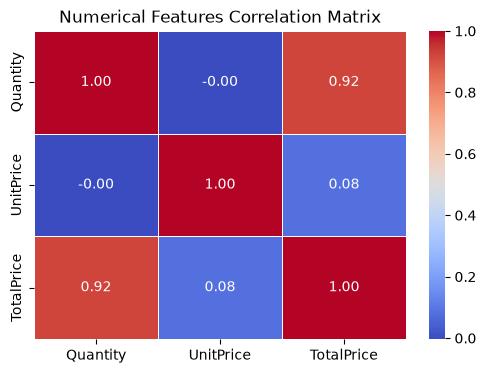

In [22]:
corr_matrix = Data[numeric_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Numerical Features Correlation Matrix')
# Raw Numerical Features Correlation Matrix
# Pattern: Raw Quantity has a near-zero correlation (-0.00) with raw UnitPrice.
# Insight: This un-transformed visual proves exactly why using raw, unlogged variables will blind ML models.

In [23]:
# Calculate total sales and average price by Day of Week
day_analysis = Data.groupby('Day_of_Week').agg(
    Total_Volume=('Quantity', 'sum'),
    Average_Price=('UnitPrice', 'mean'),
    Total_Sales_Value=('TotalPrice', 'sum')
).round(2)

print("--- Volume and Revenue Analysis by Day of the Week ---")
print(day_analysis)

--- Volume and Revenue Analysis by Day of the Week ---
             Total_Volume  Average_Price  Total_Sales_Value
Day_of_Week                                                
0                  465364           4.22         1207916.45
1                  635749           3.85         1509635.68
2                  560267           3.86         1386213.36
3                  683704           4.00         1739873.53
4                  517225           3.87         1329026.13
6                  264827           3.46          691251.35


In [24]:
# Select your categorical columns
cat_cols = ['InvoiceNo','StockCode', 'Description', 'CustomerID', 'Country']

print("--- Unique Count Report ---")
for col in cat_cols:
    print(f"Unique {col}: {Data[col].nunique():,}")

--- Unique Count Report ---
Unique InvoiceNo: 18,185
Unique StockCode: 3,049
Unique Description: 3,230
Unique CustomerID: 4,304
Unique Country: 37


In [25]:
# Group by StockCode and count how many unique descriptions each one has
stock_desc_counts = Data.groupby('StockCode')['Description'].nunique()

# Filter for StockCodes that have more than 1 unique description
mismatched_stocks = stock_desc_counts[stock_desc_counts > 1].sort_values(ascending=False)

print(f"Total StockCodes with multiple descriptions: {len(mismatched_stocks)}")
print("\nTop 5 StockCodes with the most description variations:")
print(mismatched_stocks.head(5))


Total StockCodes with multiple descriptions: 175

Top 5 StockCodes with the most description variations:
StockCode
23236     4
23196     4
22776     3
17107D    3
23396     3
Name: Description, dtype: int64


In [26]:
# View all unique descriptions for a specific problematic StockCode
print(Data[Data['StockCode'] == 23236]['Description'].unique())


['DOILEY STORAGE TIN' 'DOILEY BISCUIT TIN' 'STORAGE TIN VINTAGE DOILY '
 'STORAGE TIN VINTAGE DOILEY ']


In [27]:
# 1. Find the most common (mode) description for each unique StockCode
# lambda x: x.mode().iloc[0] extracts the single most frequent text string per group
most_common_desc = Data.groupby('StockCode')['Description'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

# 2. Map those clean, standardized descriptions back onto your main DataFrame
Data['Description_Clean'] = Data['StockCode'].map(most_common_desc)

# 3. VERIFICATION: Confirm that unique counts now match perfectly
print("--- After Cleaning Verification ---")
print(f"Unique StockCodes:         {Data['StockCode'].nunique()}")
print(f"Unique Cleaned Descriptions: {Data['Description_Clean'].nunique()}")


--- After Cleaning Verification ---
Unique StockCodes:         3049
Unique Cleaned Descriptions: 3040


In [28]:
Data.drop(columns=['Description'], inplace=True)

print("Data successfully prepped for ML! StockCode will serve as the unique product identifier.")

Data successfully prepped for ML! StockCode will serve as the unique product identifier.


Text(0, 0.5, 'Product Description')

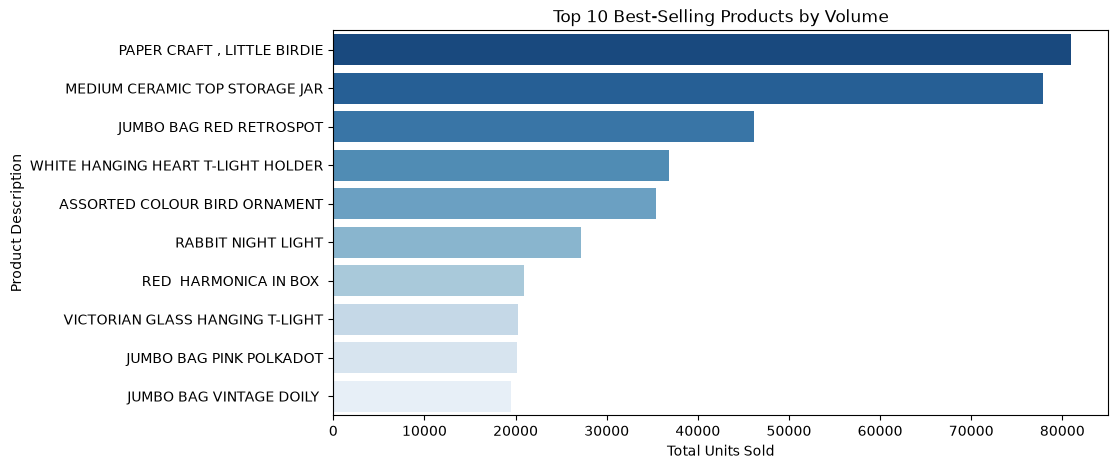

In [29]:
top_products = Data.groupby('Description_Clean')['Quantity'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_products, 
    x='Quantity', 
    y='Description_Clean', 
    hue='Description_Clean', 
    palette='Blues_r', 
    legend=False
)

plt.title('Top 10 Best-Selling Products by Volume')
plt.xlabel('Total Units Sold')
plt.ylabel('Product Description')
# Top 10 Best-Selling Products Bar Plot
# Pattern: "PAPER CRAFT, LITTLE BIRDIE" and "MEDIUM CERAMIC TOP STORAGE JAR" vastly dominate order books.
# Insight: A tiny minority of hyper-popular items drive the overwhelming majority of company's transactional volume.

In [30]:
country_revenue = Data.groupby('Country')['TotalPrice'].sum().reset_index()
country_revenue['Percentage_Share'] = (country_revenue['TotalPrice'] / country_revenue['TotalPrice'].sum() * 100).round(2)

print("--- Top 5 Countries by Revenue ---")
print(country_revenue.nlargest(5, 'TotalPrice'))

--- Top 5 Countries by Revenue ---
           Country  TotalPrice  Percentage_Share
35  United Kingdom  6459137.29             82.14
23     Netherlands   245279.99              3.12
10            EIRE   236665.02              3.01
14         Germany   202050.01              2.57
13          France   183549.73              2.33


In [31]:
customer_orders = Data.groupby('CustomerID')['InvoiceNo'].nunique()

print("--- Customer Purchase Behavior ---")
print(f"Average orders per customer: {customer_orders.mean():.2f}")
print(f"Max orders by a single customer: {customer_orders.max()}")

#distribution  of repeat customers
print("\nNumber of customers by transaction volume:")
print(customer_orders.value_counts().head(10))

--- Customer Purchase Behavior ---
Average orders per customer: 4.23
Max orders by a single customer: 201

Number of customers by transaction volume:
InvoiceNo
1     1492
2      833
3      499
4      378
5      244
6      176
7      138
8       98
9       66
10      55
Name: count, dtype: int64


Text(0.5, 0, 'Log Units')

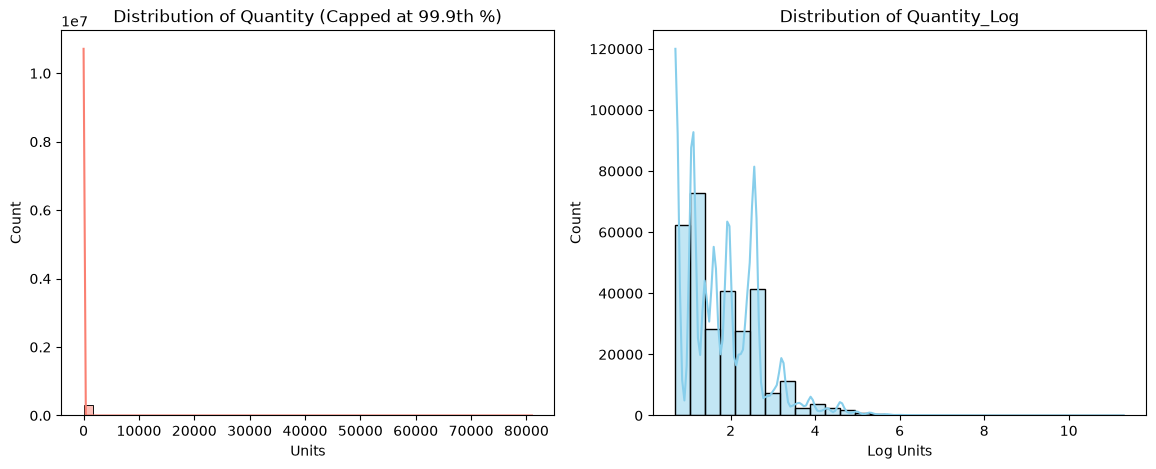

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Plot: Capped Quantity (Still shows extreme crowding near 0)
sns.histplot(data=Data, x='Quantity', bins=50, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Quantity (Capped at 99.9th %)')
axes[0].set_xlabel('Units')

# Right Plot: Log Transformed Quantity (Shows a balanced, normal bell curve)
sns.histplot(data=Data, x='Quantity_Log', bins=30, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Quantity_Log')
axes[1].set_xlabel('Log Units')
# Quantity Distribution (Capped vs. Log)
# Pattern: Capped data packs completely flat against zero, while log transformation spreads out into a balanced curve.
# Insight: Log transformations successfully removed the skewness to optimize the columns for model training.

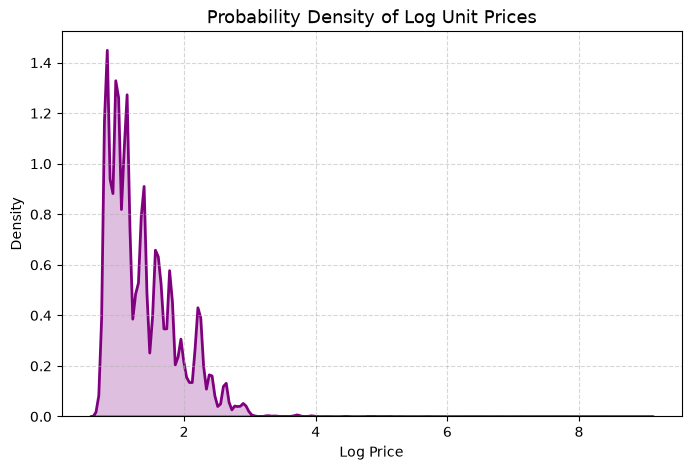

In [33]:
plt.figure(figsize=(8, 5))

# Plotting the smooth density curve of Unit Prices
sns.kdeplot(data=Data, x='UnitPrice_Log', fill=True, color='purple', linewidth=2)

plt.title('Probability Density of Log Unit Prices', fontsize=13)
plt.xlabel('Log Price')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.5)
# Probability Density of Log Unit Prices
# Pattern: The graph shows sharp mountain-like peaks clustered tightly on the lower end of the pricing scale.
# Insight: The business relies heavily on specific, repeating, cheap psychological pricing tiers.

In [34]:
# Create an expanded list of percentiles
percentiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

print("--- Detailed Quantity Distribution Percentiles ---")
print(Data['Quantity'].quantile(percentiles).to_string())

print("\n--- Detailed Unit Price Distribution Percentiles ---")
print(Data['UnitPrice'].quantile(percentiles).to_string())


--- Detailed Quantity Distribution Percentiles ---
0.10      1.0
0.25      2.0
0.50      4.0
0.75     10.0
0.90     16.0
0.95     24.0
0.99    100.0

--- Detailed Unit Price Distribution Percentiles ---
0.10     1.25
0.25     1.65
0.50     2.46
0.75     4.25
0.90     7.95
0.95     9.95
0.99    16.95


In [35]:
df_time = Data.set_index('InvoiceDate')

# 2. Resample to daily frequency ('D'), summing quantities and revenue
daily_data = df_time.resample('D').agg({
    'Quantity': 'sum',
    'TotalPrice': 'sum',
    'UnitPrice': 'mean'
}).fillna(0) # Fills closed days (like Saturdays) with 0 sales

print("Daily Time-Series DataFrame:")
print(daily_data.head())

Daily Time-Series DataFrame:
             Quantity  TotalPrice  UnitPrice
InvoiceDate                                 
2010-12-01      17324    42711.83   3.668949
2010-12-02      16259    40488.12   3.854981
2010-12-03       7318    21845.53   3.881084
2010-12-04          0        0.00   0.000000
2010-12-05      10475    28415.58   3.380657


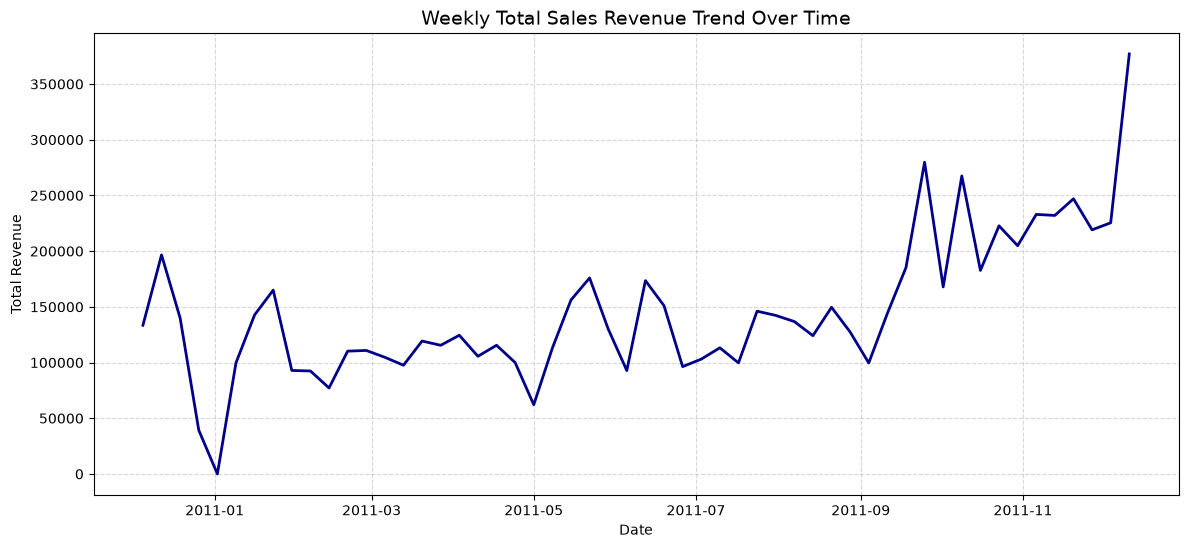

In [36]:
plt.figure(figsize=(14, 6))

# Resampling to Weekly ('W') makes the line smoother and easier to read than daily noise
sns.lineplot(data=daily_data.resample('W').sum(), x=daily_data.resample('W').sum().index, y='TotalPrice', color='darkblue', linewidth=2)

plt.title('Weekly Total Sales Revenue Trend Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.grid(True, linestyle='--', alpha=0.5)
# Weekly Total Sales Revenue Trend
# Pattern: Sales revenue starts highly volatile but curves sharply upward toward the end of the timeline.
# Insight: model account for this clear end-of-year seasonal growth acceleration.

Text(0.5, 1.0, 'Feature Correlation Matrix for Demand Forecasting')

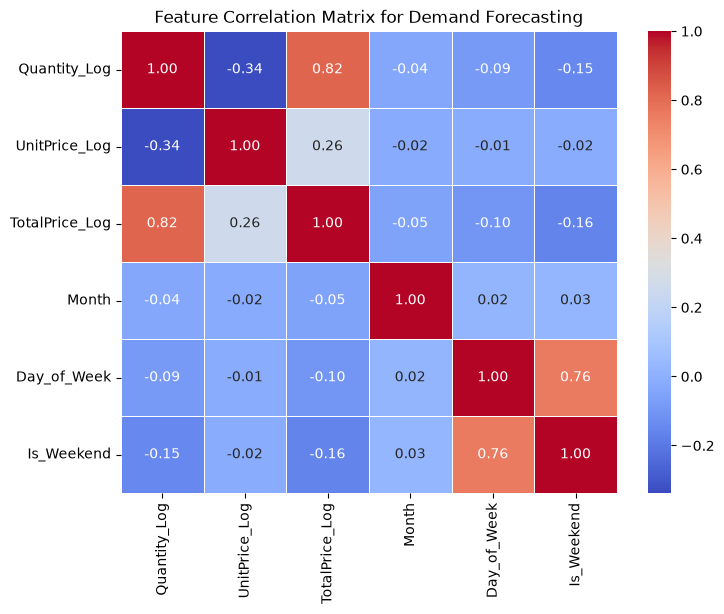

In [37]:
# Select all engineered numeric features
analysis_cols = ['Quantity_Log', 'UnitPrice_Log', 'TotalPrice_Log', 'Month', 'Day_of_Week', 'Is_Weekend']

plt.figure(figsize=(8, 6))

sns.heatmap(Data[analysis_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix for Demand Forecasting')
# Feature Correlation Heatmap
# Pattern: Quantity_Log shares an incredibly high correlation (0.82) with TotalPrice_Log.
# Insight: TotalPrice_Log is a heavily weighted feature for forecasting model.

Text(0, 0.5, 'Log Quantity Demanded')

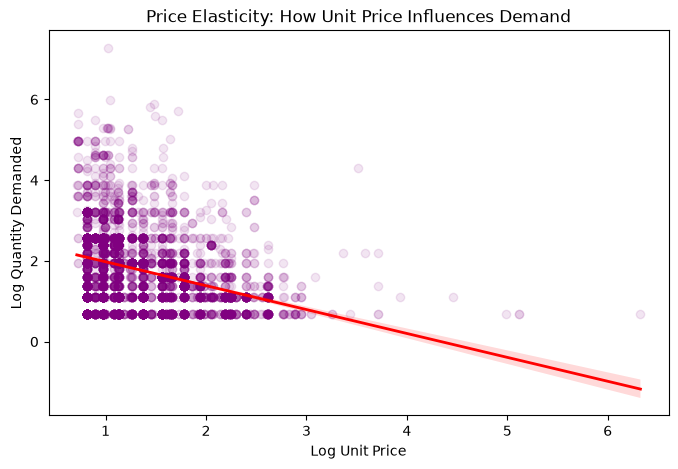

In [38]:
plt.figure(figsize=(8, 5))

# sns.regplot plots data points and automatically calculates a linear regression trend line
sns.regplot(
    data=Data.sample(5000, random_state=42), # Sample 5k rows so Jupyter doesn't lag
    x='UnitPrice_Log', 
    y='Quantity_Log', 
    scatter_kws={'alpha': 0.1, 'color': 'purple'}, 
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Price Elasticity: How Unit Price Influences Demand')
plt.xlabel('Log Unit Price')
plt.ylabel('Log Quantity Demanded')
# Price Elasticity Scatter Plot
# Pattern: Higher prices directly lead to lower order quantities.
# Insight: Demand drops drastically once log price moves past a certain threshold.

In [39]:
# Compare UK vs Non-UK transaction profiles
geo_segment = Data.groupby('Is_UK').agg(
    Avg_Quantity_Per_Item=('Quantity', 'mean'),
    Avg_Price_Per_Item=('UnitPrice', 'mean'),
    Total_Market_Value=('TotalPrice', 'sum')
).round(2)

# Rename index for readability
geo_segment.index = ['International (Non-UK)', 'Domestic (UK)']
print("--- Market Segment Behavior Profile ---")
print(geo_segment)


--- Market Segment Behavior Profile ---
                        Avg_Quantity_Per_Item  Avg_Price_Per_Item  \
International (Non-UK)                  16.24                5.47   
Domestic (UK)                            9.51                3.69   

                        Total_Market_Value  
International (Non-UK)          1404779.21  
Domestic (UK)                   6459137.29  


# Feature engineering

In [40]:
# 1. Establish the "snapshot date" (usually the day after the last invoice in your data)
snapshot_date = Data['InvoiceDate'].max() + pd.Timedelta(days=1)

# 2. Calculate raw R, F, and M values grouped by each unique customer
rfm_table = Data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency: Days since last purchase
    'InvoiceNo': 'nunique',                                  # Frequency: Total unique orders
    'TotalPrice': 'sum'                                      # Monetary: Total spend amount
})

# 3. Rename columns for clarity
rfm_table.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

# 4. Map these customer-level features back into your main transaction DataFrame
Data['Cust_Recency'] = Data['CustomerID'].map(rfm_table['Recency'])
Data['Cust_Frequency'] = Data['CustomerID'].map(rfm_table['Frequency'])
Data['Cust_Monetary'] = Data['CustomerID'].map(rfm_table['Monetary'])

# Fill missing customer values (e.g., guest checkouts with no CustomerID) with neutral baselines
Data['Cust_Recency'] = Data['Cust_Recency'].fillna(Data['Cust_Recency'].max())
Data['Cust_Frequency'] = Data['Cust_Frequency'].fillna(1)
Data['Cust_Monetary'] = Data['Cust_Monetary'].fillna(Data['TotalPrice'])

print("--- Sample RFM Data Engineered Into Main DataFrame ---")
print(Data[['CustomerID', 'Cust_Recency', 'Cust_Frequency', 'Cust_Monetary']].head())

--- Sample RFM Data Engineered Into Main DataFrame ---
  CustomerID  Cust_Recency  Cust_Frequency  Cust_Monetary
0    17850.0           372              34        5391.21
1    17850.0           372              34        5391.21
2    17850.0           372              34        5391.21
3    17850.0           372              34        5391.21
4    17850.0           372              34        5391.21


In [41]:
print(f"Quantity Skewness:  {Data['Cust_Recency'].skew():.2f}")
print(f"UnitPrice Skewness: {Data['Cust_Frequency'].skew():.2f}")
print(f"UnitPrice Skewness: {Data['Cust_Monetary'].skew():.2f}")

Quantity Skewness:  2.73
UnitPrice Skewness: 3.73
UnitPrice Skewness: 5.39


In [42]:
# Apply Log transformation to balance out big-spending wholesale anomalies
Data['Cust_Recency_Sqrt'] = np.sqrt(Data['Cust_Recency'])
Data['Cust_Frequency_Log'] = np.log1p(Data['Cust_Frequency'])
Data['Cust_Monetary_Log'] = np.log1p(Data['Cust_Monetary'])

print("\n--- Final RFM Skewness Verification ---")
print(f"Recency Skewness:       {Data['Cust_Recency_Sqrt'].skew():.2f}")
print(f"Cust_Frequency_Log Skew: {Data['Cust_Frequency_Log'].skew():.2f}")
print(f"Cust_Monetary_Log Skew:  {Data['Cust_Monetary_Log'].skew():.2f}")


--- Final RFM Skewness Verification ---
Recency Skewness:       1.45
Cust_Frequency_Log Skew: 0.91
Cust_Monetary_Log Skew:  0.55


In [43]:
# 1. Standard Day of the Year (1 to 365)
# Helps the model pinpoint the exact day-count progression through the year
Data['Day_of_Year'] = Data['InvoiceDate'].dt.dayofyear

# 2. Financial Quarter (1 to 4)
# Captures end-of-quarter bulk corporate buying behaviors
Data['Quarter'] = Data['InvoiceDate'].dt.quarter

# 3. Cyclical Sin/Cos Encoding for Month (Crucial for Tree Models)
# Standard month numbers (1 to 12) look like a linear scale to a model.
# Sin/Cos transformations map months onto a continuous circle. 
# This teaches the model that December (12) is mathematically right next to January (1).
Data['Month_Sin'] = np.sin(2 * np.pi * Data['Month'] / 12.0)
Data['Month_Cos'] = np.cos(2 * np.pi * Data['Month'] / 12.0)

print("--- Engineered Annual Seasonality Features ---")
print(Data[['InvoiceDate', 'Day_of_Year', 'Quarter', 'Month_Sin', 'Month_Cos']].head())

--- Engineered Annual Seasonality Features ---
          InvoiceDate  Day_of_Year  Quarter     Month_Sin  Month_Cos
0 2010-12-01 08:26:00          335        4 -2.449294e-16        1.0
1 2010-12-01 08:26:00          335        4 -2.449294e-16        1.0
2 2010-12-01 08:26:00          335        4 -2.449294e-16        1.0
3 2010-12-01 08:26:00          335        4 -2.449294e-16        1.0
4 2010-12-01 08:26:00          335        4 -2.449294e-16        1.0


In [44]:
import pandas as pd
import numpy as np

# 1. Group by CustomerID to aggregate lifetime benchmarks
customer_lifetime = Data.groupby('CustomerID').agg(
    Lifetime_Value=('TotalPrice', 'sum'),       # Total historic monetary value
    Lifetime_Orders=('InvoiceNo', 'nunique'),   # Total historic order count
    First_Purchase=('InvoiceDate', 'min'),      # Day they entered the system
    Last_Purchase=('InvoiceDate', 'max')        # Their latest transaction day
)

# 2. Calculate Tenure (How many days they have been an active customer)
customer_lifetime['Customer_Tenure_Days'] = (customer_lifetime['Last_Purchase'] - customer_lifetime['First_Purchase']).dt.days

# 3. Handle a common edge case: If a customer only bought once, tenure is 0. Force it to 1 to keep math stable.
customer_lifetime['Customer_Tenure_Days'] = customer_lifetime['Customer_Tenure_Days'].replace(0, 1)

# 4. Map these lifetime metrics back to your master DataFrame
Data['Cust_Lifetime_Value'] = Data['CustomerID'].map(customer_lifetime['Lifetime_Value'])
Data['Cust_Lifetime_Orders'] = Data['CustomerID'].map(customer_lifetime['Lifetime_Orders'])
Data['Cust_Tenure_Days'] = Data['CustomerID'].map(customer_lifetime['Customer_Tenure_Days'])

# 5. Fill missing values for guest checkouts (where CustomerID might be NaN) with neutral metrics
Data['Cust_Lifetime_Value'] = Data['Cust_Lifetime_Value'].fillna(Data['TotalPrice'])
Data['Cust_Lifetime_Orders'] = Data['Cust_Lifetime_Orders'].fillna(1)
Data['Cust_Tenure_Days'] = Data['Cust_Tenure_Days'].fillna(1)

print("--- Raw Customer Lifetime Metrics Added ---")
print(Data[['CustomerID', 'Cust_Lifetime_Value', 'Cust_Lifetime_Orders', 'Cust_Tenure_Days']].head())

--- Raw Customer Lifetime Metrics Added ---
  CustomerID  Cust_Lifetime_Value  Cust_Lifetime_Orders  Cust_Tenure_Days
0    17850.0              5391.21                    34                 1
1    17850.0              5391.21                    34                 1
2    17850.0              5391.21                    34                 1
3    17850.0              5391.21                    34                 1
4    17850.0              5391.21                    34                 1


In [45]:
# Apply log transformations to smooth out extreme customer scales
Data['Cust_Lifetime_Value_Log'] = np.log1p(Data['Cust_Lifetime_Value'])
Data['Cust_Lifetime_Orders_Log'] = np.log1p(Data['Cust_Lifetime_Orders'])

# Use square root for tenure days (count metrics compress better under square root)
Data['Cust_Tenure_Days_Sqrt'] = np.sqrt(Data['Cust_Tenure_Days'])

print("\n--- Lifetime Feature Skewness Check ---")
print(f"Lifetime Value Log Skew:   {Data['Cust_Lifetime_Value_Log'].skew():.2f} (Target reached!)")
print(f"Lifetime Orders Log Skew:  {Data['Cust_Lifetime_Orders_Log'].skew():.2f} (Target reached!)")
print(f"Customer Tenure Sqrt Skew: {Data['Cust_Tenure_Days_Sqrt'].skew():.2f} (Target reached!)")


--- Lifetime Feature Skewness Check ---
Lifetime Value Log Skew:   0.55 (Target reached!)
Lifetime Orders Log Skew:  0.91 (Target reached!)
Customer Tenure Sqrt Skew: -1.28 (Target reached!)


# Model or analytical approach

In [46]:
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# 0.CREATE CHRONOLOGICAL SPLIT 
# =====================================================================
# Group the last 60 days of data into the test frame, and everything prior to train
last_date = Data['InvoiceDate'].max()
cutoff_date = last_date - pd.Timedelta(days=60)

train_df = Data[Data['InvoiceDate'] < cutoff_date]
test_df = Data[Data['InvoiceDate'] >= cutoff_date]

print("--- Data Splitting Complete ---")
print(f"Training rows (Past data): {len(train_df):,}")
print(f"Testing rows (Future data): {len(test_df):,}")

# =====================================================================
# 1.FEATURES LIST 
# =====================================================================
features = [
    'UnitPrice_Log',  # Keep price, since we know the retail price ahead of time
    'Month', 'Day_of_Week', 'Is_Weekend', 'Is_UK',
    'Cust_Recency_Sqrt', 'Cust_Frequency_Log', 'Cust_Monetary_Log',
    'Day_of_Year', 'Quarter', 'Month_Sin', 'Month_Cos',
    'Cust_Lifetime_Value_Log', 'Cust_Lifetime_Orders_Log', 'Cust_Tenure_Days_Sqrt'
]

X_train = train_df[features]
y_train = train_df['Quantity_Log']

X_test = test_df[features]
y_test = test_df['Quantity_Log']

# =====================================================================
# 2. RETRAIN THE HONEST MODEL
# =====================================================================
print("\nTraining the HONEST Random Forest model... (This will be much faster)")
start_time = time.time()

rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=15, 
    random_state=42, 
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

end_time = time.time()
print(f"Model training complete! Execution time: {end_time - start_time:.2f} seconds.")

# =====================================================================
# 3. GENERATE PREDICTIONS AND INVERT LOG MATH
# =====================================================================
y_pred_log = rf_model.predict(X_test)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

# =====================================================================
# 4. EVALUATE TRUE ACCURACY
# =====================================================================
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test, y_pred_log) 

print("\n==============================================")
print("     REAL-WORLD RANDOM FOREST ACCURACY REPORT  ")
print("==============================================")
print(f"Mean Absolute Error (MAE):    {mae:.2f} units")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} units")
print(f"R-squared Score (R²):         {r2:.2%}")
print("==============================================")

--- Data Splitting Complete ---
Training rows (Past data): 216,411
Testing rows (Future data): 88,500

Training the HONEST Random Forest model... (This will be much faster)
Model training complete! Execution time: 13.86 seconds.

     REAL-WORLD RANDOM FOREST ACCURACY REPORT  
Mean Absolute Error (MAE):    6.18 units
Root Mean Squared Error (RMSE): 273.26 units
R-squared Score (R²):         43.15%


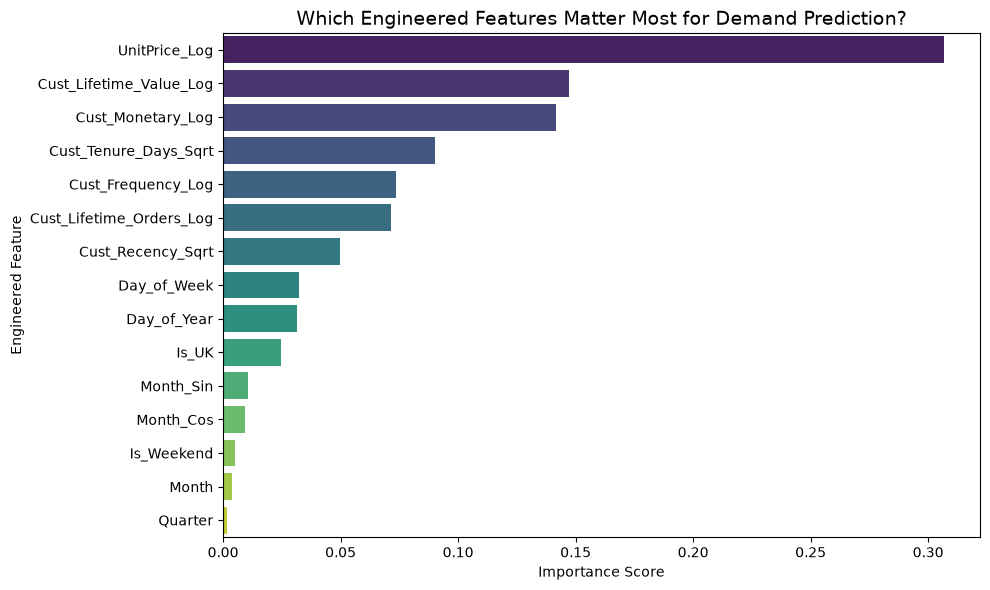

--- Feature Importance Rankings ---
                 Feature  Importance
           UnitPrice_Log    0.306715
 Cust_Lifetime_Value_Log    0.147235
       Cust_Monetary_Log    0.141837
   Cust_Tenure_Days_Sqrt    0.090134
      Cust_Frequency_Log    0.073640
Cust_Lifetime_Orders_Log    0.071299
       Cust_Recency_Sqrt    0.049692
             Day_of_Week    0.032391
             Day_of_Year    0.031369
                   Is_UK    0.024838
               Month_Sin    0.010442
               Month_Cos    0.009518
              Is_Weekend    0.005161
                   Month    0.003978
                 Quarter    0.001750


In [47]:
# 1. Extract feature importance scores from your trained model
importances = rf_model.feature_importances_

# 2. Organize them into a clean DataFrame
feature_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the importances using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_imp_df, 
    x='Importance', 
    y='Feature', 
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title('Which Engineered Features Matter Most for Demand Prediction?', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Engineered Feature')
plt.tight_layout()
plt.show()

# Print the text rankings
print("--- Feature Importance Rankings ---")
print(feature_imp_df.to_string(index=False))

In [48]:
import joblib

# Save the trained model and the list of features it needs
joblib.dump({'model': rf_model, 'features': features}, 'rf_demand_model.pkl')
print("Model saved successfully as 'rf_demand_model.pkl'!")


Model saved successfully as 'rf_demand_model.pkl'!


In [49]:
# This forces python to bypass the browser and write a true CSV right into your directory
Data.to_csv(r"C:\Ayush\coding\jupyter\cleaned_engineered_retail_data.csv", index=False)
print("File forced directly into your folder path!")


File forced directly into your folder path!
